GBmap Reference Dataset Preparation

This notebook downloads and prepares the GBmap (GSE211376) reference dataset
for use with Cell2location spatial mapping.

Data source: Ruiz-Moreno et al. 2022
GEO Accession: GSE211376
Direct download links from NCBI GEO

Last run: 2026-04-09

In [1]:
# Cell 1 - Setup and dependencies
import os
import urllib.request
import gzip
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import time
import hashlib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")
print(f"Scanpy version: {sc.__version__}")
print(f"Time started: {time.strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded successfully!
Scanpy version: 1.10.3
Time started: 2026-04-09 00:32:51


In [2]:
# Cell 2 - Define paths
PROJECT_DIR = "/projectnb/ds596/projects/Team_7"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
REF_DIR = os.path.join(DATA_DIR, "GBmap_reference")

# Create directory if it doesn't exist
os.makedirs(REF_DIR, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Reference directory: {REF_DIR}")
print(f"Directory exists: {os.path.exists(REF_DIR)}")

Project directory: /projectnb/ds596/projects/Team_7
Reference directory: /projectnb/ds596/projects/Team_7/data/GBmap_reference
Directory exists: True


In [3]:
# Cell 3 - Download GBmap files 
"""
DOWNLOAD GBMAP FROM NCBI GEO
============================
Source: GSE211376
Links verified: 2026-04-09
"""

# Direct download links from GEO
# These are the official supplementary files for GSE211376
URLS = {
    "counts": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE211nnn/GSE211376/suppl/GSE211376_raw_counts_Ruiz2022_all_samples_filtered_cells.tsv.gz",
    "metadata": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE211nnn/GSE211376/suppl/GSE211376_metadata_Ruiz2022_all_samples_filtered_cells.csv.gz"
}

# Output filenames
FILES = {
    "counts": os.path.join(REF_DIR, "GBmap_raw_counts.tsv.gz"),
    "metadata": os.path.join(REF_DIR, "GBmap_metadata.csv.gz")
}

print("Downloading GBmap reference data from NCBI GEO...")
print("="*60)

for name, url in URLS.items():
    output_file = FILES[name]
    print(f"\nDownloading {name}...")
    print(f"  URL: {url}")
    print(f"  Destination: {output_file}")
    
    if os.path.exists(output_file):
        file_size = os.path.getsize(output_file) / (1024*1024)
        print(f"  ⚠️ File already exists: {file_size:.1f} MB")
        overwrite = input(f"  Overwrite? (y/n): ")
        if overwrite.lower() != 'y':
            print(f"  Skipping {name}")
            continue
    
    try:
        # Download with progress indicator
        urllib.request.urlretrieve(url, output_file)
        file_size = os.path.getsize(output_file) / (1024*1024)
        print(f"  ✓ Downloaded: {file_size:.1f} MB")
        
        # Calculate MD5 checksum for verification
        md5_hash = hashlib.md5()
        with open(output_file, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                md5_hash.update(chunk)
        print(f"  MD5: {md5_hash.hexdigest()}")
        
    except Exception as e:
        print(f"  ✗ Download failed: {e}")
        print(f"  Try manual download from: {url}")

print("\n✅ Download phase complete!")


  URL: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE211nnn/GSE211376/suppl/GSE211376_raw_counts_Ruiz2022_all_samples_filtered_cells.tsv.gz
  Destination: /projectnb/ds596/projects/Team_7/data/GBmap_reference/GBmap_raw_counts.tsv.gz
  ✓ Downloaded: 110.6 MB
  MD5: e7331189d51dd3d0666702f084bb072b

  URL: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE211nnn/GSE211376/suppl/GSE211376_metadata_Ruiz2022_all_samples_filtered_cells.csv.gz
  Destination: /projectnb/ds596/projects/Team_7/data/GBmap_reference/GBmap_metadata.csv.gz
  ✓ Downloaded: 0.2 MB
  MD5: a843853f1d3eb7d0a0499f7a05504599

✅ Download phase complete!


In [ ]:
# Cell 4 - Verify downloaded files
print("Verifying downloaded files...")
print("="*60)

for name, filepath in FILES.items():
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / (1024*1024)
        print(f"✓ {name}: {size:.1f} MB")
        
        # Test reading first few lines
        if name == "metadata":
            with gzip.open(filepath, 'rt') as f:
                first_line = f.readline().strip()
                print(f"  First line: {first_line[:100]}...")
        else:
            with gzip.open(filepath, 'rt') as f:
                first_line = f.readline().strip()
                print(f"  First line (first 100 chars): {first_line[:100]}...")
    else:
        print(f"✗ {name}: NOT FOUND")

print("\n✅ Verification complete!")

Verifying downloaded files...
✓ counts: 110.6 MB
  First line (first 100 chars): NH16-2366_AAACCCAAGATCGCCC-1	NH16-2366_AAACCCACACACTTAG-1	NH16-2366_AAACCCATCTTCCTAA-1	NH16-2366_AAA...
✓ metadata: 0.2 MB
  First line: predicted.high_hierarchy,patient...

✅ Verification complete!


In [5]:
# Cell 5 - Load metadata and inspect cell types
print("Loading metadata...")
metadata = pd.read_csv(FILES["metadata"], compression='gzip')
print(f"Metadata shape: {metadata.shape}")
print(f"Columns: {metadata.columns.tolist()}")

print("\n" + "="*60)
print("CELL TYPE DISTRIBUTION (predicted.high_hierarchy)")
print("="*60)

cell_type_counts = metadata['predicted.high_hierarchy'].value_counts()
for ct, count in cell_type_counts.items():
    print(f"  {ct:25s}: {count:6,} cells ({count/len(metadata)*100:.1f}%)")

print(f"\nTotal cells: {len(metadata):,}")
print(f"Unique patients: {metadata['patient'].nunique()}")

Loading metadata...
Metadata shape: (39355, 2)
Columns: ['predicted.high_hierarchy', 'patient']

CELL TYPE DISTRIBUTION (predicted.high_hierarchy)
  Oligodendrocyte          : 12,716 cells (32.3%)
  OPC-like                 :  5,201 cells (13.2%)
  TAM-MG                   :  4,011 cells (10.2%)
  TAM-BDM                  :  3,215 cells (8.2%)
  MES-like                 :  2,790 cells (7.1%)
  AC-like                  :  2,752 cells (7.0%)
  NPC-like                 :  2,687 cells (6.8%)
  Neuron                   :  2,325 cells (5.9%)
  OPC                      :  1,587 cells (4.0%)
  Astrocyte                :  1,091 cells (2.8%)
  Endothelial              :    394 cells (1.0%)
  CD4/CD8                  :    353 cells (0.9%)
  Pericyte                 :    224 cells (0.6%)
  DC                       :      9 cells (0.0%)

Total cells: 39,355
Unique patients: 11


In [6]:
# Cell 6 - Load counts and create AnnData
# Load count matrix
print("Loading count matrix (this takes 2-5 minutes)...")
start_time = time.time()

counts = pd.read_csv(FILES["counts"], compression='gzip', sep='\t', index_col=0)
print(f"Counts shape: {counts.shape[0]:,} genes × {counts.shape[1]:,} cells")
print(f"Load time: {time.time() - start_time:.1f} seconds")

# Create AnnData (cells × genes format)
print("\nCreating AnnData object...")
adata_ref = ad.AnnData(
    X=counts.T.values.astype(np.int32),  # Transpose: cells as rows
    obs=metadata,
    var=pd.DataFrame(index=counts.index)
)

# Add clean cell type column
adata_ref.obs['cell_type'] = adata_ref.obs['predicted.high_hierarchy']

print(f"AnnData shape: {adata_ref.shape[0]:,} cells, {adata_ref.shape[1]:,} genes")

Loading count matrix (this takes 2-5 minutes)...
Counts shape: 27,102 genes × 39,355 cells
Load time: 398.3 seconds

Creating AnnData object...
AnnData shape: 39,355 cells, 27,102 genes


In [7]:
# Cell 7 - Quality control filtering
print("Before filtering:")
print(f"  Cells: {adata_ref.n_obs:,}")
print(f"  Genes: {adata_ref.n_vars:,}")

# Filter cells with too few genes
sc.pp.filter_cells(adata_ref, min_genes=200)
print(f"\nAfter filtering cells with <200 genes: {adata_ref.n_obs:,} cells")

# Filter genes expressed in too few cells
sc.pp.filter_genes(adata_ref, min_cells=3)
print(f"After filtering genes expressed in <3 cells: {adata_ref.n_vars:,} genes")

print(f"\nFinal reference shape: {adata_ref.shape[0]:,} cells, {adata_ref.shape[1]:,} genes")

Before filtering:
  Cells: 39,355
  Genes: 27,102

After filtering cells with <200 genes: 39,355 cells
After filtering genes expressed in <3 cells: 27,093 genes

Final reference shape: 39,355 cells, 27,093 genes


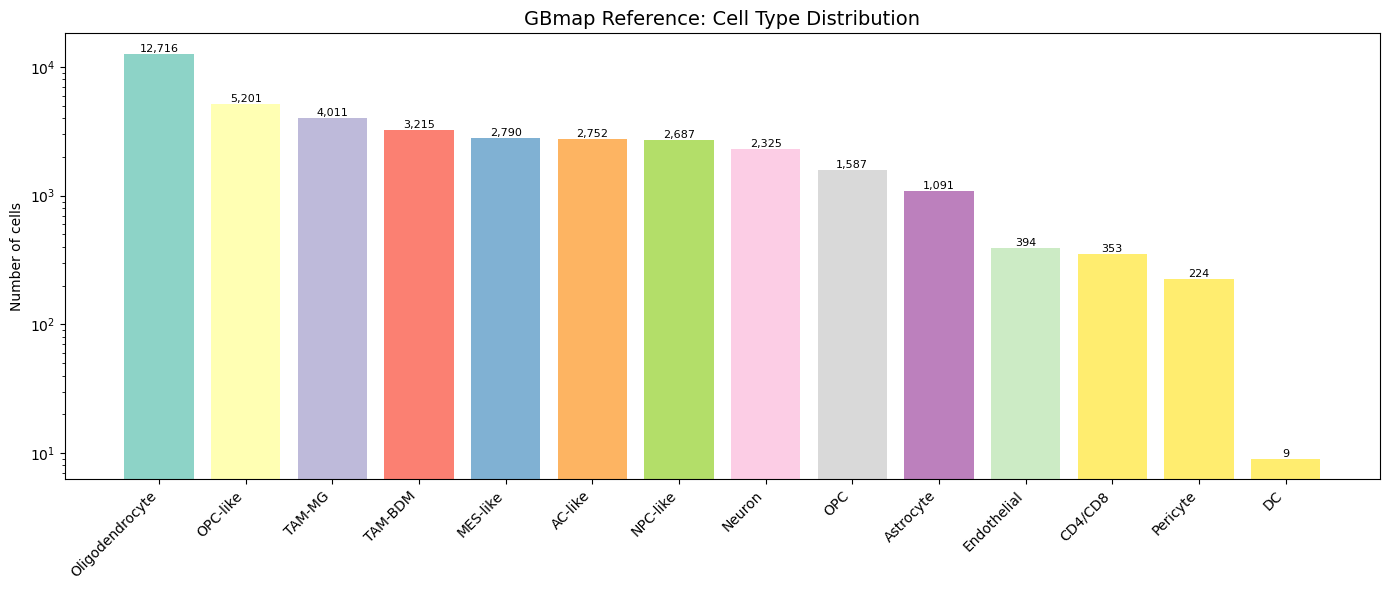

Plot saved to: /projectnb/ds596/projects/Team_7/data/GBmap_reference/cell_type_distribution.png


In [8]:
# Cell 8: Visualize cell type distribution
# Plot
fig, ax = plt.subplots(figsize=(14, 6))
cell_type_counts = adata_ref.obs['cell_type'].value_counts()
colors = plt.cm.Set3(range(len(cell_type_counts)))
bars = ax.bar(range(len(cell_type_counts)), cell_type_counts.values, color=colors)

ax.set_xticks(range(len(cell_type_counts)))
ax.set_xticklabels(cell_type_counts.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of cells')
ax.set_title('GBmap Reference: Cell Type Distribution', fontsize=14)
ax.set_yscale('log')

# Add value labels
for bar, count in zip(bars, cell_type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plot_path = os.path.join(REF_DIR, "cell_type_distribution.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

In [9]:
# Cell 9 - Save processed reference for Cell2location
# Main reference file
output_file = os.path.join(REF_DIR, "GBmap_reference_for_cell2location.h5ad")
adata_ref.write(output_file)
print(f"✅ Saved main reference: {output_file}")
print(f"   File size: {os.path.getsize(output_file) / (1024*1024):.1f} MB")

# Malignant-only subset
malignant_types = ['MES-like', 'AC-like', 'NPC-like', 'OPC-like']
malignant_mask = adata_ref.obs['cell_type'].isin(malignant_types)
adata_malignant = adata_ref[malignant_mask].copy()

if adata_malignant.n_obs > 0:
    malignant_file = os.path.join(REF_DIR, "GBmap_malignant_only.h5ad")
    adata_malignant.write(malignant_file)
    print(f"✅ Saved malignant-only reference: {malignant_file}")
    print(f"   {adata_malignant.n_obs:,} malignant cells ({adata_malignant.n_obs/adata_ref.n_obs*100:.1f}%)")

✅ Saved main reference: /projectnb/ds596/projects/Team_7/data/GBmap_reference/GBmap_reference_for_cell2location.h5ad
   File size: 4071.6 MB
✅ Saved malignant-only reference: /projectnb/ds596/projects/Team_7/data/GBmap_reference/GBmap_malignant_only.h5ad
   13,430 malignant cells (34.1%)


In [12]:
# Cell 10 - Create aligned versions with spatial data (FIXED)
import numpy as np

# Load spatial data
visium_dir = os.path.join(DATA_DIR, "humanGlioblastoma")
spatial_file = os.path.join(visium_dir, "Parent_Visium_Human_Glioblastoma_filtered_feature_bc_matrix.h5")

if os.path.exists(spatial_file):
    print("Loading Visium spatial data...")
    adata_spatial = sc.read_visium(visium_dir, 
                                    count_file='Parent_Visium_Human_Glioblastoma_filtered_feature_bc_matrix.h5', 
                                    load_images=True)
    print(f"Spatial data: {adata_spatial.shape[0]:,} spots, {adata_spatial.shape[1]:,} genes")
    
    # Make gene names unique (fixes the InvalidIndexError)
    print("\nMaking gene names unique...")
    adata_spatial.var_names_make_unique()
    adata_ref.var_names_make_unique()
    print(f"  Spatial genes after uniquify: {adata_spatial.n_vars:,}")
    print(f"  Reference genes after uniquify: {adata_ref.n_vars:,}")
    
    # Find common genes
    common_genes = np.intersect1d(adata_spatial.var_names, adata_ref.var_names)
    print(f"Common genes: {len(common_genes):,}")
    
    # Subset both datasets to common genes
    print("Subsetting to common genes...")
    adata_ref_aligned = adata_ref[:, common_genes].copy()
    adata_spatial_aligned = adata_spatial[:, common_genes].copy()
    
    print(f"Aligned reference: {adata_ref_aligned.shape}")
    print(f"Aligned spatial: {adata_spatial_aligned.shape}")
    
    # Save aligned versions
    ref_aligned = os.path.join(REF_DIR, "GBmap_reference_aligned.h5ad")
    spatial_aligned = os.path.join(visium_dir, "spatial_data_aligned.h5ad")
    
    adata_ref_aligned.write(ref_aligned)
    adata_spatial_aligned.write(spatial_aligned)
    
    print(f"\n✅ Saved aligned reference: {ref_aligned}")
    print(f"✅ Saved aligned spatial: {spatial_aligned}")
    
    # Optional: Verify the aligned files
    print("\nVerifying aligned files...")
    test_ref = sc.read(ref_aligned)
    test_spatial = sc.read(spatial_aligned)
    print(f"  Reference: {test_ref.shape[0]:,} cells, {test_ref.shape[1]:,} genes")
    print(f"  Spatial: {test_spatial.shape[0]:,} spots, {test_spatial.shape[1]:,} genes")
    
else:
    print("Spatial data not found - skipping alignment step")
    print(f"Expected location: {spatial_file}")
    print("\nFiles in humanGlioblastoma directory:")
    if os.path.exists(visium_dir):
        for f in os.listdir(visium_dir):
            print(f"  {f}")

Loading Visium spatial data...
Spatial data: 3,468 spots, 36,601 genes

Making gene names unique...
  Spatial genes after uniquify: 36,601
  Reference genes after uniquify: 27,093
Common genes: 25,731
Subsetting to common genes...
Aligned reference: (39355, 25731)
Aligned spatial: (3468, 25731)

✅ Saved aligned reference: /projectnb/ds596/projects/Team_7/data/GBmap_reference/GBmap_reference_aligned.h5ad
✅ Saved aligned spatial: /projectnb/ds596/projects/Team_7/data/humanGlioblastoma/spatial_data_aligned.h5ad

Verifying aligned files...
  Reference: 39,355 cells, 25,731 genes
  Spatial: 3,468 spots, 25,731 genes


In [13]:
# Cell 11 - Summary
print("GBMAP REFERENCE PREPARATION COMPLETE")

print(f"\n📁 Location: {REF_DIR}")
print(f"\n📊 Reference summary:")
print(f"   Total cells: {adata_ref.n_obs:,}")
print(f"   Total genes: {adata_ref.n_vars:,}")
print(f"   Cell types: {adata_ref.obs['cell_type'].nunique()}")

print(f"\n📋 Cell type composition:")
for ct, count in adata_ref.obs['cell_type'].value_counts().items():
    print(f"   {ct:25s}: {count:6,} cells")

print(f"\n📁 Files created:")
for f in sorted(os.listdir(REF_DIR)):
    if f.endswith('.h5ad') or f.endswith('.png'):
        size = os.path.getsize(os.path.join(REF_DIR, f)) / (1024*1024)
        print(f"   {f:40s} ({size:.1f} MB)")

print(f"\n✅ Ready for Cell2location!")
print(f"\nTo load in a new session:")
print(f"   import scanpy as sc")
print(f"   adata = sc.read('{output_file}')")
print(f"\nRun completed at: {time.strftime('%Y-%m-%d %H:%M:%S')}")

GBMAP REFERENCE PREPARATION COMPLETE

📁 Location: /projectnb/ds596/projects/Team_7/data/GBmap_reference

📊 Reference summary:
   Total cells: 39,355
   Total genes: 27,093
   Cell types: 14

📋 Cell type composition:
   Oligodendrocyte          : 12,716 cells
   OPC-like                 :  5,201 cells
   TAM-MG                   :  4,011 cells
   TAM-BDM                  :  3,215 cells
   MES-like                 :  2,790 cells
   AC-like                  :  2,752 cells
   NPC-like                 :  2,687 cells
   Neuron                   :  2,325 cells
   OPC                      :  1,587 cells
   Astrocyte                :  1,091 cells
   Endothelial              :    394 cells
   CD4/CD8                  :    353 cells
   Pericyte                 :    224 cells
   DC                       :      9 cells

📁 Files created:
   GBmap_malignant_only.h5ad                (1390.3 MB)
   GBmap_reference_aligned.h5ad             (3867.0 MB)
   GBmap_reference_for_cell2location.h5ad   (4071.6 

In [14]:
# Verify the saved reference loads correctly
print("Testing reference loading...")
test_adata = sc.read(os.path.join(REF_DIR, "GBmap_reference_for_cell2location.h5ad"))
print(f"✓ Successfully loaded: {test_adata.shape[0]:,} cells, {test_adata.shape[1]:,} genes")
print(f"✓ Cell types: {test_adata.obs['cell_type'].unique().tolist()}")
print("\nAll good! Reference is ready.")

Testing reference loading...
✓ Successfully loaded: 39,355 cells, 27,093 genes
✓ Cell types: ['TAM-MG', 'CD4/CD8', 'Oligodendrocyte', 'TAM-BDM', 'OPC-like', 'Pericyte', 'Endothelial', 'MES-like', 'NPC-like', 'AC-like', 'OPC', 'Neuron', 'DC', 'Astrocyte']

All good! Reference is ready.
